# EGU26 Hydrological GNN — Ablation & Baseline Notebook (v2)
**목적**: 미호천 유역 Chl-a 예측 시계열 모델 아키텍처 비교 (Transformer vs GRU vs LightGBM)
**주요 반영 사항**:
- Log 변환(np.log1p) 및 Expm1 역변환을 통한 R², MAE 스케일 정규화 완료
- Lookback Window 짧게 재설정
**실행 환경**: Google Colab (GPU 런타임 권장)

---
## 실행 전 체크리스트
1. `런타임 → 런타임 유형 변경 → GPU` 설정
2. 깃허브 최신 버전 유지


## 1. 환경 세팅

In [3]:
import os
import sys

# 코랩(Colab) 환경 vs 로컬(Local) 환경 동적 경로 인식
if os.path.exists('/content'):
    if os.path.exists('EGU26-SWAT-GNN'):
        import shutil
        shutil.rmtree('EGU26-SWAT-GNN')
    !git clone https://github.com/kona0107/EGU26-SWAT-GNN.git
    MODULE_PATH = os.path.abspath('EGU26-SWAT-GNN/script/src/gnn_project')
    DATA_PATH   = os.path.abspath('EGU26-SWAT-GNN/script/data')
else:
    # 로컬 환경 (Windows 등)에서 실행 시
    # 현재 작업 디렉토리에 따라 동적으로 데이터 폴더 탐색
    possible_paths = [
        os.path.abspath('../../data'),                  # script/src/gnn_project 에서 실행 시
        os.path.abspath('script/data'),                 # 프로젝트 루트(EGU26) 에서 실행 시
        os.path.abspath('./data')                       # script 폴더에서 실행 시
    ]
    DATA_PATH = None
    for p in possible_paths:
        if os.path.exists(os.path.join(p, 'outlet.csv')):
            DATA_PATH = p
            break
    if DATA_PATH is None:
        DATA_PATH = './script/data'  # Fallback

    MODULE_PATH = os.path.abspath('../../src/gnn_project') if os.path.exists('../../src/gnn_project') else os.path.abspath('.')

if MODULE_PATH not in sys.path:
    sys.path.insert(0, MODULE_PATH)

OUTLET_CSV   = os.path.join(DATA_PATH, 'outlet.csv')
UPSTREAM_CSV = os.path.join(DATA_PATH, 'upstream.csv')

print(f'데이터 폴더 경로: {DATA_PATH}')
print('Outlet CSV 존재 여부:', os.path.exists(OUTLET_CSV))
print('Upstream CSV 존재 여부:', os.path.exists(UPSTREAM_CSV))


Cloning into 'EGU26-SWAT-GNN'...
remote: Enumerating objects: 289, done.
remote: Counting objects: 100% (289/289), done.
remote: Compressing objects: 100% (155/155), done.
remote: Total 289 (delta 110), reused 240 (delta 75), pack-reused 0 (from 0)
Receiving objects: 100% (289/289), 20.89 MiB | 25.74 MiB/s, done.
Resolving deltas: 100% (110/110), done.
데이터 폴더 경로: /content/EGU26-SWAT-GNN/script/data
Outlet CSV 존재 여부: True
Upstream CSV 존재 여부: True


In [4]:
# 의존 패키지 설치 (PyTorch Geometric)
import torch
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available : {torch.cuda.is_available()}')

!pip install torch_geometric -q
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv \
    -f https://data.pyg.org/whl/torch-$(python -c "import torch; print(torch.__version__)").html -q

!pip install lightgbm -q


PyTorch version: 2.10.0+cpu
CUDA available : False
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.4/682.4 kB 34.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.2/828.2 kB 42.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.9/306.9 kB 20.2 MB/s eta 0:00:00


In [5]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from data.dataset import (
    load_real_data, prepare_and_split_data,
    FEATURE_DIM, OUTLET_IDX, N_NODES
)
from models.temporal import TransformerBaseline
from models.st_gcn   import SpatioTemporalHybridGNN

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

Using device: cpu


## 2. 데이터 로딩 및 분할

In [7]:
from data.dataset import (
    load_real_data,
    prepare_and_split_data,
    FEATURE_DIM,
    RAW_DIM,
    OUTLET_IDX,
    N_NODES,
)

 # ── 하이퍼파라미터 ───────────────────────────
LOOKBACK    = 5   # 관측 윈도우 크기 축소 (주 단위 최적 4~6 탐색)RAIN_RATIO = 0.7
VAL_RATIO   = 0.15
BATCH_SIZE  = 16
# ─────────────────────────────────────────────

if (not os.path.exists(OUTLET_CSV)) or (not os.path.exists(UPSTREAM_CSV)):
    colab_data_path = '/content/EGU26-SWAT-GNN/script/data'
    if os.path.exists(os.path.join(colab_data_path, 'outlet.csv')):
        OUTLET_CSV = os.path.join(colab_data_path, 'outlet.csv')
        UPSTREAM_CSV = os.path.join(colab_data_path, 'upstream.csv')
    else:
        raise FileNotFoundError(
            f'CSV 파일을 찾지 못했습니다. OUTLET_CSV={OUTLET_CSV}, UPSTREAM_CSV={UPSTREAM_CSV}'
        )

print('Resolved OUTLET_CSV  :', OUTLET_CSV)
print('Resolved UPSTREAM_CSV:', UPSTREAM_CSV)

raw_features, dates = load_real_data(OUTLET_CSV, UPSTREAM_CSV)
print(f'총 관측 날짜 수 (T) : {len(dates)}')
print(f'raw_features shape : {raw_features.shape}  → 기대: [T, 29, {RAW_DIM}]')
print(f'날짜 범위           : {dates[0]}  ~  {dates[-1]}')

Resolved OUTLET_CSV  : /content/EGU26-SWAT-GNN/script/data/outlet.csv
Resolved UPSTREAM_CSV: /content/EGU26-SWAT-GNN/script/data/upstream.csv
총 관측 날짜 수 (T) : 617
raw_features shape : (617, 29, 15)  → 기대: [T, 29, 15]
날짜 범위           : 2007-01-05 00:00:00  ~  2024-12-17 00:00:00


/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:102: RuntimeWarning: Outlet/upstream date ranges do not perfectly match. Using the shared 617 dates only.
  warnings.warn(
/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:145: RuntimeWarning: Some upstream dates are missing subbasins; affected node features will remain zero-padded. Examples: 2017-06-21 (26 subs)
  warnings.warn(


In [8]:
train_ds, val_ds, test_ds, scaler_out, scaler_target = prepare_and_split_data(
    raw_features,
    outlet_node_idx = OUTLET_IDX,
    lookback_window = LOOKBACK,
    train_ratio     = TRAIN_RATIO,
    val_ratio       = VAL_RATIO,
    apply_log1p     = True
)

print(f'Train / Val / Test 샘플 수: {len(train_ds)} / {len(val_ds)} / {len(test_ds)}')

# DataLoader
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

# 배치 shape 확인
bx, by, bidx = next(iter(train_loader))
print(f'배치 X shape: {bx.shape}   (기대: [B, L, 29, 11])')
print(f'배치 y shape: {by.shape}   (기대: [B, 1])')


Train / Val / Test 샘플 수: 426 / 87 / 89
배치 X shape: torch.Size([16, 5, 29, 16])   (기대: [B, L, 29, 11])
배치 y shape: torch.Size([16, 1])   (기대: [B, 1])


## 3. Graph Edge 정의

In [9]:
# Upstream → Downstream 단방향 엣지
edges_list = [
    (20, 5), (5, 23), (21, 24), (22, 24), (24, 23), (23, 25), (4, 25), (19, 25),
    (25, 27), (15, 3), (3, 27), (6, 27), (10, 27), (16, 27), (27, 0), (0, 28),
    (26, 2), (2, 1), (12, 1), (1, 28), (7, 28), (8, 28), (9, 28)
]
source = torch.tensor([e[0] for e in edges_list], dtype=torch.long)
target = torch.tensor([e[1] for e in edges_list], dtype=torch.long)
edge_index = torch.stack([source, target], dim=0).to(DEVICE)
print('Edge index shape:', edge_index.shape)
print('방향: Upstream → Downstream (단방향)')

Edge index shape: torch.Size([2, 23])
방향: Upstream → Downstream (단방향)


## 3.5 비딥러닝(Tree) 앙상블 베이스라인 평가
시계열/공간 피처를 단순 1D Flatten으로 다루었을 때의 성능 비교

In [10]:
import lightgbm as lgb
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 트리 앙상블을 위한 플래튼(Flatten) 데이터 변환 함수
def extract_flat_features(dataset):
    X, Y = [], []
    for x_seq, y_target, _ in dataset:
        X.append(x_seq.numpy().flatten())  # 시공간 피처 1D로 쫙 펼치기
        Y.append(y_target.numpy())
    return np.array(X), np.array(Y)

X_train_flat, Y_train_flat = extract_flat_features(train_ds)
X_test_flat, Y_test_flat   = extract_flat_features(test_ds)

lgb_train = lgb.Dataset(X_train_flat, label=Y_train_flat.ravel())
params = {
    'objective': 'regression',
    'metric': 'mse',
    'learning_rate': 0.05,
    'num_leaves': 15,
    'random_state': 42,
    'verbose': -1
}
gbm = lgb.train(params, lgb_train, num_boost_round=100)
preds_lgb_scaled = gbm.predict(X_test_flat)

# 역변환 평가 (expm1 적용)
# 모델에 들어간 target은 스케일링 + log1p 된 상태임
true_lgb = np.expm1(scaler_target.inverse_transform(Y_test_flat.reshape(-1, 1)).ravel())
pred_lgb = np.expm1(scaler_target.inverse_transform(preds_lgb_scaled.reshape(-1, 1)).ravel())

print('=' * 40)
print(f'[LightGBM Baseline] R² Score:   {r2_score(true_lgb, pred_lgb):.4f}')
print(f'[LightGBM Baseline] RMSE(μg/L): {np.sqrt(mean_squared_error(true_lgb, pred_lgb)):.4f}')
print(f'[LightGBM Baseline] MAE (μg/L): {mean_absolute_error(true_lgb, pred_lgb):.4f}')
print('=' * 40)


[LightGBM Baseline] R² Score:   0.2970
[LightGBM Baseline] RMSE(μg/L): 46.1223
[LightGBM Baseline] MAE (μg/L): 28.4850


## 4. 모델 초기화

In [12]:
# ── 하이퍼파라미터 ───────────────────────────
IN_FEATURES     = FEATURE_DIM
TEMPORAL_HIDDEN = 64
GCN_HIDDEN      = 32
NUM_EPOCHS      = 200
LR              = 5e-4
PATIENCE        = 30
# ─────────────────────────────────────────────

# Model A: Transformer 기반 하이브리드 GNN
model_trans = SpatioTemporalHybridGNN(
    in_features      = IN_FEATURES,
    temporal_hidden  = TEMPORAL_HIDDEN,
    gcn_hidden       = GCN_HIDDEN,
    temporal_type    = 'transformer'
).to(DEVICE)

# Model B: GRU 기반 하이브리드 GNN
model_gru = SpatioTemporalHybridGNN(
    in_features      = IN_FEATURES,
    temporal_hidden  = TEMPORAL_HIDDEN,
    gcn_hidden       = GCN_HIDDEN,
    temporal_type    = 'gru'
).to(DEVICE)

print(f'Transformer 모델 파라미터: {sum(p.numel() for p in model_trans.parameters() if p.requires_grad):,}')
print(f'GRU 모델 파라미터:         {sum(p.numel() for p in model_gru.parameters() if p.requires_grad):,}')


Transformer 모델 파라미터: 74,785
GRU 모델 파라미터:         47,457


## 5. 학습 루프

In [13]:
def train_one_epoch(model, loader, optimizer, criterion, edge_index=None):
    model.train()
    total_loss = 0.0
    for x_batch, y_batch, _ in loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        optimizer.zero_grad()
        if edge_index is not None:
            preds = model(x_batch, edge_index, outlet_node_idx=OUTLET_IDX)
        else:
            preds = model(x_batch, outlet_node_idx=OUTLET_IDX)
        loss = criterion(preds, y_batch.view_as(preds))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(x_batch)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, edge_index=None):
    model.eval()
    total_loss = 0.0
    for x_batch, y_batch, _ in loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        if edge_index is not None:
            preds = model(x_batch, edge_index, outlet_node_idx=OUTLET_IDX)
        else:
            preds = model(x_batch, outlet_node_idx=OUTLET_IDX)
        loss = criterion(preds, y_batch.view_as(preds))
        total_loss += loss.item() * len(x_batch)
    return total_loss / len(loader.dataset)

print('학습 함수 정의 완료')

학습 함수 정의 완료


In [14]:
import time
def train_and_eval_model(model_name, model, train_loader, val_loader, test_loader, edge_index):
    print(f'\n>>>>> Training {model_name} <<<<<')
    criterion  = nn.MSELoss()
    optimizer  = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

    best_val_loss  = float('inf')
    patience_count = 0

    start_time = time.time()
    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, edge_index)
        val_loss   = evaluate(model, val_loader, criterion, edge_index)
        scheduler.step(val_loss)

        if epoch % 20 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d} | Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f}')

        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            patience_count = 0
            torch.save(model.state_dict(), f'best_{model_name}.pt')
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                print(f'  [Early Stopping] Epoch {epoch} (Best Val: {best_val_loss:.4f})')
                break

    model.load_state_dict(torch.load(f'best_{model_name}.pt', map_location=DEVICE))
    print(f'  [Done] Training Done: {time.time() - start_time:.1f} sec')
    return model

model_trans = train_and_eval_model('Transformer_GNN', model_trans, train_loader, val_loader, test_loader, edge_index)
model_gru   = train_and_eval_model('GRU_GNN', model_gru, train_loader, val_loader, test_loader, edge_index)



>>>>> Training Transformer_GNN <<<<<
  Epoch   1 | Train MSE: 0.8567 | Val MSE: 0.5317
  Epoch  20 | Train MSE: 0.2390 | Val MSE: 0.2761
  Epoch  40 | Train MSE: 0.1065 | Val MSE: 0.3750
  [Early Stopping] Epoch 42 (Best Val: 0.2556)
  [Done] Training Done: 92.9 sec

>>>>> Training GRU_GNN <<<<<
  Epoch   1 | Train MSE: 1.0358 | Val MSE: 0.7854
  Epoch  20 | Train MSE: 0.2985 | Val MSE: 0.2449
  Epoch  40 | Train MSE: 0.2485 | Val MSE: 0.2576
  [Early Stopping] Epoch 47 (Best Val: 0.2415)
  [Done] Training Done: 45.3 sec


## 6. 학습 곡선 시각화

In [ ]:
# 시각화 생략 (모델 2개 비교를 위해 평가 파트로 직행)


## 7. 테스트 평가

In [16]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def get_inverse_metrics(dataset_loader, model_list, edge_index):
    # Retrieve raw responses
    all_true = []
    all_preds_trans = []
    all_preds_gru   = []

    for m in model_list:
        m.eval()

    with torch.no_grad():
        for x_batch, y_batch, _ in dataset_loader:
            x_batch = x_batch.to(DEVICE)

            p_trans = model_list[0](x_batch, edge_index, outlet_node_idx=OUTLET_IDX).cpu().numpy()
            p_gru   = model_list[1](x_batch, edge_index, outlet_node_idx=OUTLET_IDX).cpu().numpy()

            all_true.append(y_batch.numpy())
            all_preds_trans.append(p_trans)
            all_preds_gru.append(p_gru)

    # Concat
    all_true = np.concatenate(all_true, axis=0) # [N, 1]
    all_preds_trans = np.concatenate(all_preds_trans, axis=0)
    all_preds_gru   = np.concatenate(all_preds_gru, axis=0)

    # [핵심] 스케일 역변환 + Expm1 (원래 단위인 μg/L로 복원)
    true_raw  = np.expm1(scaler_target.inverse_transform(all_true)).ravel()
    trans_raw = np.expm1(scaler_target.inverse_transform(all_preds_trans)).ravel()
    gru_raw   = np.expm1(scaler_target.inverse_transform(all_preds_gru)).ravel()

    return true_raw, trans_raw, gru_raw

def print_metrics(model_name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f'[{model_name}] R²: {r2:7.4f} | RMSE: {rmse:6.2f} | MAE: {mae:6.2f}')

# Train Evaluation
tr_true, tr_trans, tr_gru = get_inverse_metrics(train_loader, [model_trans, model_gru], edge_index)
print("=== [Train Set] 원단위 (μg/L) 성능 지표 ===")
print_metrics("Trans-GNN", tr_true, tr_trans)
print_metrics("GRU-GNN  ", tr_true, tr_gru)
print()

# Test Evaluation
te_true, te_trans, te_gru = get_inverse_metrics(test_loader, [model_trans, model_gru], edge_index)
print("=== [Test Set] 원단위 (μg/L) 성능 지표 ===")
print_metrics("Trans-GNN", te_true, te_trans)
print_metrics("GRU-GNN  ", te_true, te_gru)

# Persistence Baseline (역변환 적용)
def get_persistence(dataset):
    preds, trues = [], []
    for i in range(len(dataset)):
        x_seq, y_target, _ = dataset[i]
        last_chl_scaled = x_seq[-1, -1, 5].item()
        preds.append(last_chl_scaled)
        trues.append(y_target.item())

    p_raw = np.expm1(scaler_target.inverse_transform(np.array(preds).reshape(-1,1))).ravel()
    t_raw = np.expm1(scaler_target.inverse_transform(np.array(trues).reshape(-1,1))).ravel()
    return t_raw, p_raw

persist_true, persist_pred = get_persistence(test_ds)
print_metrics("Persist. ", persist_true, persist_pred)


=== [Train Set] 원단위 (μg/L) 성능 지표 ===
[Trans-GNN] R²:  0.5215 | RMSE:  46.38 | MAE:  26.99
[GRU-GNN  ] R²:  0.4738 | RMSE:  48.64 | MAE:  28.57

=== [Test Set] 원단위 (μg/L) 성능 지표 ===
[Trans-GNN] R²:  0.4673 | RMSE:  40.15 | MAE:  26.03
[GRU-GNN  ] R²:  0.4080 | RMSE:  42.32 | MAE:  27.24
[Persist. ] R²:  0.2238 | RMSE:  48.46 | MAE:  30.60


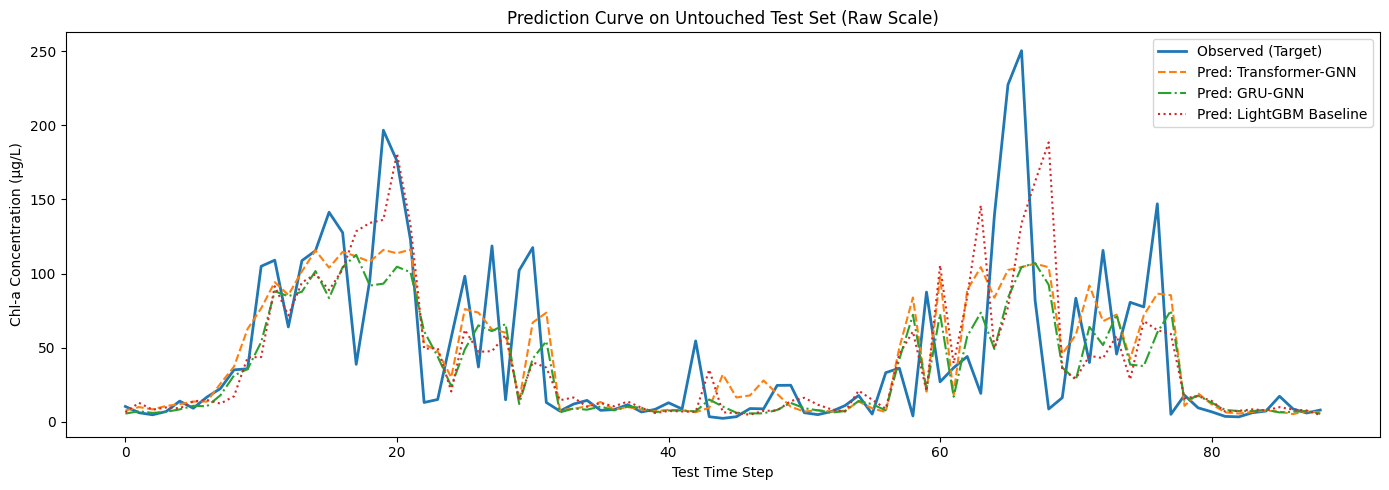

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(te_true, label='Observed (Target)', linewidth=2.0)
plt.plot(te_trans, label='Pred: Transformer-GNN', linestyle='--')
plt.plot(te_gru, label='Pred: GRU-GNN', linestyle='-.')
plt.plot(pred_lgb, label='Pred: LightGBM Baseline', linestyle=':')

plt.xlabel('Test Time Step')
plt.ylabel('Chl-a Concentration (μg/L)')
plt.title('Prediction Curve on Untouched Test Set (Raw Scale)')
plt.legend()
plt.tight_layout()
plt.savefig('test_comparison.png', dpi=150)
plt.show()


# 1. 학습/평가 기록 함수

이 셀은 epoch loss, overall metric, high-chl metric까지 같이 저장

In [18]:
import copy
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def inverse_target(arr_2d, scaler_target):
    return np.expm1(scaler_target.inverse_transform(arr_2d)).ravel()

@torch.no_grad()
def predict_raw(model, loader, scaler_target, edge_index=None):
    model.eval()
    all_true, all_pred, all_idx = [], [], []

    for x_batch, y_batch, target_idx in loader:
        x_batch = x_batch.to(DEVICE)
        if edge_index is not None:
            pred = model(x_batch, edge_index, outlet_node_idx=OUTLET_IDX).cpu().numpy()
        else:
            pred = model(x_batch, outlet_node_idx=OUTLET_IDX).cpu().numpy()

        all_true.append(y_batch.numpy())
        all_pred.append(pred)
        all_idx.extend(target_idx.numpy().tolist())

    y_true_scaled = np.concatenate(all_true, axis=0)
    y_pred_scaled = np.concatenate(all_pred, axis=0)

    y_true_raw = inverse_target(y_true_scaled, scaler_target)
    y_pred_raw = inverse_target(y_pred_scaled, scaler_target)

    return y_true_raw, y_pred_raw, np.array(all_idx, dtype=int)

def compute_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }

def compute_high_metrics(y_true, y_pred, threshold=100):
    mask = y_true >= threshold
    if mask.sum() == 0:
        return {
            "high_count": 0,
            "high_R2": np.nan,
            "high_RMSE": np.nan,
            "high_MAE": np.nan,
        }
    m = compute_metrics(y_true[mask], y_pred[mask])
    return {
        "high_count": int(mask.sum()),
        "high_R2": m["R2"],
        "high_RMSE": m["RMSE"],
        "high_MAE": m["MAE"],
    }

def make_weighted_mse_loss(high_threshold_raw=100, high_weight=3.0):
    high_threshold_scaled = scaler_target.transform(
        np.array([[np.log1p(high_threshold_raw)]], dtype=np.float32)
    )[0, 0]

    def weighted_mse(pred, target):
        weights = torch.ones_like(target)
        weights = torch.where(target >= high_threshold_scaled, high_weight, weights)
        return torch.mean(weights * (pred - target) ** 2)

    return weighted_mse

def make_huber_loss(delta=1.0):
    return nn.HuberLoss(delta=delta)

def train_model_with_history(model_name, model, train_loader, val_loader, edge_index=None, criterion=None):
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

    best_val = float("inf")
    best_state = None
    patience_count = 0
    history = []

    start = time.time()

    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        train_loss_sum = 0.0

        for x_batch, y_batch, _ in train_loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            pred = model(x_batch, edge_index, outlet_node_idx=OUTLET_IDX)
            loss = criterion(pred, y_batch.view_as(pred))
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * len(x_batch)

        train_loss = train_loss_sum / len(train_loader.dataset)

        model.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for x_batch, y_batch, _ in val_loader:
                x_batch = x_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                pred = model(x_batch, edge_index, outlet_node_idx=OUTLET_IDX)
                loss = criterion(pred, y_batch.view_as(pred))
                val_loss_sum += loss.item() * len(x_batch)

        val_loss = val_loss_sum / len(val_loader.dataset)
        scheduler.step(val_loss)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "lr": optimizer.param_groups[0]["lr"],
        })

        if epoch == 1 or epoch % 20 == 0:
            print(f"[{model_name}] epoch={epoch:3d} train={train_loss:.4f} val={val_loss:.4f}")

        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                print(f"[{model_name}] Early stopping at epoch {epoch}, best val={best_val:.4f}")
                break

    model.load_state_dict(best_state)
    print(f"[{model_name}] done in {time.time() - start:.1f}s")

    history_df = pd.DataFrame(history)
    return model, history_df


# 2. lookback별 데이터/로더 생성 함수

In [19]:
from torch.utils.data import DataLoader
from data.dataset import load_real_data, prepare_and_split_data

def build_loaders_for_lookback(lookback):
    raw_features, dates_local = load_real_data(OUTLET_CSV, UPSTREAM_CSV)

    train_ds_local, val_ds_local, test_ds_local, scaler_out_local, scaler_target_local = prepare_and_split_data(
        raw_features,
        outlet_node_idx=OUTLET_IDX,
        lookback_window=lookback,
        train_ratio=0.7,
        val_ratio=0.15,
        apply_log1p=True
    )

    train_loader_local = DataLoader(train_ds_local, batch_size=BATCH_SIZE, shuffle=False)
    val_loader_local = DataLoader(val_ds_local, batch_size=BATCH_SIZE, shuffle=False)
    test_loader_local = DataLoader(test_ds_local, batch_size=BATCH_SIZE, shuffle=False)

    return {
        "dates": dates_local,
        "train_ds": train_ds_local,
        "val_ds": val_ds_local,
        "test_ds": test_ds_local,
        "train_loader": train_loader_local,
        "val_loader": val_loader_local,
        "test_loader": test_loader_local,
        "scaler_target": scaler_target_local,
    }


# 3. 단일 실험 실행 함수
모델 종류와 loss 종류 변경 가능

In [20]:
from models.st_gcn import SpatioTemporalHybridGNN

def run_single_experiment(
    lookback,
    temporal_type="gru",
    loss_type="mse",
    high_threshold=100,
    high_weight=3.0,
    delta=1.0,
):
    bundle = build_loaders_for_lookback(lookback)

    global scaler_target
    scaler_target = bundle["scaler_target"]

    model = SpatioTemporalHybridGNN(
        in_features=FEATURE_DIM,
        temporal_hidden=TEMPORAL_HIDDEN,
        gcn_hidden=GCN_HIDDEN,
        temporal_type=temporal_type
    ).to(DEVICE)

    if loss_type == "mse":
        criterion = nn.MSELoss()
    elif loss_type == "huber":
        criterion = make_huber_loss(delta=delta)
    elif loss_type == "weighted_mse":
        criterion = make_weighted_mse_loss(high_threshold_raw=high_threshold, high_weight=high_weight)
    else:
        raise ValueError(f"Unknown loss_type: {loss_type}")

    run_name = f"{temporal_type}_lb{lookback}_{loss_type}"
    model, history_df = train_model_with_history(
        run_name,
        model,
        bundle["train_loader"],
        bundle["val_loader"],
        edge_index=edge_index,
        criterion=criterion,
    )

    tr_true, tr_pred, _ = predict_raw(model, bundle["train_loader"], bundle["scaler_target"], edge_index=edge_index)
    va_true, va_pred, _ = predict_raw(model, bundle["val_loader"], bundle["scaler_target"], edge_index=edge_index)
    te_true, te_pred, te_idx = predict_raw(model, bundle["test_loader"], bundle["scaler_target"], edge_index=edge_index)

    result = {
        "run_name": run_name,
        "temporal_type": temporal_type,
        "lookback": lookback,
        "loss_type": loss_type,
        "train_R2": compute_metrics(tr_true, tr_pred)["R2"],
        "train_RMSE": compute_metrics(tr_true, tr_pred)["RMSE"],
        "train_MAE": compute_metrics(tr_true, tr_pred)["MAE"],
        "val_R2": compute_metrics(va_true, va_pred)["R2"],
        "val_RMSE": compute_metrics(va_true, va_pred)["RMSE"],
        "val_MAE": compute_metrics(va_true, va_pred)["MAE"],
        "test_R2": compute_metrics(te_true, te_pred)["R2"],
        "test_RMSE": compute_metrics(te_true, te_pred)["RMSE"],
        "test_MAE": compute_metrics(te_true, te_pred)["MAE"],
        **compute_high_metrics(te_true, te_pred, threshold=100),
    }

    pred_df = pd.DataFrame({
        "target_idx": te_idx,
        "date": [bundle["dates"][i] for i in te_idx],
        "y_true": te_true,
        "y_pred": te_pred,
        "abs_err": np.abs(te_pred - te_true),
    })

    return result, history_df, pred_df, model


In [21]:
# lookback 비교 실험

LOOKBACK_CANDIDATES = [5, 14, 21, 28, 42]

all_results = []
all_histories = {}
all_test_preds = {}

for lb in LOOKBACK_CANDIDATES:
    print(f"\n===== RUN: GRU-GNN / lookback={lb} / MSE =====")
    result, history_df, pred_df, model_obj = run_single_experiment(
        lookback=lb,
        temporal_type="gru",
        loss_type="mse",
    )
    all_results.append(result)
    all_histories[result["run_name"]] = history_df
    all_test_preds[result["run_name"]] = pred_df

lookback_result_df = pd.DataFrame(all_results).sort_values("lookback")
display(lookback_result_df)

lookback_result_df.to_csv("exp_lookback_compare_gru.csv", index=False)
print("Saved: exp_lookback_compare_gru.csv")



===== RUN: GRU-GNN / lookback=5 / MSE =====


/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:102: RuntimeWarning: Outlet/upstream date ranges do not perfectly match. Using the shared 617 dates only.
  warnings.warn(
/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:145: RuntimeWarning: Some upstream dates are missing subbasins; affected node features will remain zero-padded. Examples: 2017-06-21 (26 subs)
  warnings.warn(


[gru_lb5_mse] epoch=  1 train=0.9898 val=0.7927
[gru_lb5_mse] epoch= 20 train=0.3002 val=0.2600
[gru_lb5_mse] epoch= 40 train=0.2512 val=0.2696
[gru_lb5_mse] Early stopping at epoch 41, best val=0.2506
[gru_lb5_mse] done in 40.0s

===== RUN: GRU-GNN / lookback=14 / MSE =====


/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:102: RuntimeWarning: Outlet/upstream date ranges do not perfectly match. Using the shared 617 dates only.
  warnings.warn(
/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:145: RuntimeWarning: Some upstream dates are missing subbasins; affected node features will remain zero-padded. Examples: 2017-06-21 (26 subs)
  warnings.warn(


[gru_lb14_mse] epoch=  1 train=1.0121 val=0.7785
[gru_lb14_mse] epoch= 20 train=0.3079 val=0.2682
[gru_lb14_mse] epoch= 40 train=0.2391 val=0.2908
[gru_lb14_mse] Early stopping at epoch 48, best val=0.2642
[gru_lb14_mse] done in 132.3s

===== RUN: GRU-GNN / lookback=21 / MSE =====


...

[gru_lb28_mse] epoch=  1 train=1.0239 val=0.8523
[gru_lb28_mse] epoch= 20 train=0.2976 val=0.2830
[gru_lb28_mse] epoch= 40 train=0.2424 val=0.3192
[gru_lb28_mse] Early stopping at epoch 42, best val=0.2560
[gru_lb28_mse] done in 181.2s

===== RUN: GRU-GNN / lookback=42 / MSE =====


/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:102: RuntimeWarning: Outlet/upstream date ranges do not perfectly match. Using the shared 617 dates only.
  warnings.warn(
/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:145: RuntimeWarning: Some upstream dates are missing subbasins; affected node features will remain zero-padded. Examples: 2017-06-21 (26 subs)
  warnings.warn(


[gru_lb42_mse] epoch=  1 train=1.0310 val=0.7040
[gru_lb42_mse] epoch= 20 train=0.2887 val=0.1897
[gru_lb42_mse] epoch= 40 train=0.2107 val=0.2659
[gru_lb42_mse] Early stopping at epoch 47, best val=0.1878
[gru_lb42_mse] done in 286.8s


,run_name,temporal_type,lookback,loss_type,train_R2,train_RMSE,train_MAE,val_R2,val_RMSE,val_MAE,test_R2,test_RMSE,test_MAE,high_count,high_R2,high_RMSE,high_MAE
0,gru_lb5_mse,gru,5,mse,0.470525,49.678878,29.521597,0.451744,40.349511,23.851704,0.401164,42.568458,27.004864,17,-2.145089,76.281218,63.399757
1,gru_lb14_mse,gru,14,mse,0.488720,49.175303,29.053745,0.463519,40.944988,26.624146,0.412798,43.519441,28.097132,17,-1.911126,73.389110,60.353058
2,gru_lb21_mse,gru,21,mse,0.513957,47.682142,28.181938,0.408965,44.183770,27.934786,0.332074,46.235724,29.693733,12,-2.680898,88.667003,78.429939
3,gru_lb28_mse,gru,28,mse,0.469718,50.086729,30.232594,0.445681,43.950988,27.307400,0.161950,47.072420,28.442442,8,-3.731184,113.089109,108.858444
4,gru_lb42_mse,gru,42,mse,0.488088,48.858700,28.588881,0.626234,25.986545,16.291935,0.217940,47.170941,27.090996,5,-4.695504,126.228792,121.997032


Saved: exp_lookback_compare_gru.csv


In [22]:
best_lookback = 14

loss_exp_settings = [
    {"loss_type": "mse"},
    {"loss_type": "huber", "delta": 1.0},
    {"loss_type": "weighted_mse", "high_threshold": 80, "high_weight": 2.0},
    {"loss_type": "weighted_mse", "high_threshold": 100, "high_weight": 3.0},
]

loss_results = []
loss_histories = {}
loss_test_preds = {}

for cfg in loss_exp_settings:
    print(f"\n===== RUN: GRU-GNN / lb={best_lookback} / {cfg} =====")
    result, history_df, pred_df, model_obj = run_single_experiment(
        lookback=best_lookback,
        temporal_type="gru",
        **cfg
    )
    loss_results.append(result)
    loss_histories[result["run_name"]] = history_df
    loss_test_preds[result["run_name"]] = pred_df

loss_result_df = pd.DataFrame(loss_results).sort_values(["loss_type", "test_R2"])
display(loss_result_df)

loss_result_df.to_csv("exp_loss_compare_gru.csv", index=False)
print("Saved: exp_loss_compare_gru.csv")



===== RUN: GRU-GNN / lb=14 / {'loss_type': 'mse'} =====


/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:102: RuntimeWarning: Outlet/upstream date ranges do not perfectly match. Using the shared 617 dates only.
  warnings.warn(
/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:145: RuntimeWarning: Some upstream dates are missing subbasins; affected node features will remain zero-padded. Examples: 2017-06-21 (26 subs)
  warnings.warn(


[gru_lb14_mse] epoch=  1 train=1.0085 val=0.7702
[gru_lb14_mse] epoch= 20 train=0.2977 val=0.2732
[gru_lb14_mse] epoch= 40 train=0.2459 val=0.2884
[gru_lb14_mse] Early stopping at epoch 47, best val=0.2704
[gru_lb14_mse] done in 106.7s

===== RUN: GRU-GNN / lb=14 / {'loss_type': 'huber', 'delta': 1.0} =====


/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:102: RuntimeWarning: Outlet/upstream date ranges do not perfectly match. Using the shared 617 dates only.
  warnings.warn(
/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:145: RuntimeWarning: Some upstream dates are missing subbasins; affected node features will remain zero-padded. Examples: 2017-06-21 (26 subs)
  warnings.warn(


[gru_lb14_huber] epoch=  1 train=0.4936 val=0.3925
[gru_lb14_huber] epoch= 20 train=0.1368 val=0.1457
[gru_lb14_huber] epoch= 40 train=0.1065 val=0.1518
[gru_lb14_huber] Early stopping at epoch 42, best val=0.1370
[gru_lb14_huber] done in 95.5s

===== RUN: GRU-GNN / lb=14 / {'loss_type': 'weighted_mse', 'high_threshold': 80, 'high_weight': 2.0} =====


...

[gru_lb14_weighted_mse] epoch=  1 train=1.4671 val=1.0834
[gru_lb14_weighted_mse] epoch= 20 train=0.3691 val=0.3762
[gru_lb14_weighted_mse] epoch= 40 train=0.3186 val=0.3847
[gru_lb14_weighted_mse] Early stopping at epoch 45, best val=0.3635
[gru_lb14_weighted_mse] done in 103.2s

===== RUN: GRU-GNN / lb=14 / {'loss_type': 'weighted_mse', 'high_threshold': 100, 'high_weight': 3.0} =====


/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:102: RuntimeWarning: Outlet/upstream date ranges do not perfectly match. Using the shared 617 dates only.
  warnings.warn(
/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:145: RuntimeWarning: Some upstream dates are missing subbasins; affected node features will remain zero-padded. Examples: 2017-06-21 (26 subs)
  warnings.warn(


[gru_lb14_weighted_mse] epoch=  1 train=2.2138 val=1.6172
[gru_lb14_weighted_mse] epoch= 20 train=0.4056 val=0.4082
[gru_lb14_weighted_mse] epoch= 40 train=0.3203 val=0.4420
[gru_lb14_weighted_mse] Early stopping at epoch 49, best val=0.4075
[gru_lb14_weighted_mse] done in 112.2s


,run_name,temporal_type,lookback,loss_type,train_R2,train_RMSE,train_MAE,val_R2,val_RMSE,val_MAE,test_R2,test_RMSE,test_MAE,high_count,high_R2,high_RMSE,high_MAE
1,gru_lb14_huber,gru,14,huber,0.507912,48.243490,29.033779,0.421780,42.507948,27.015146,0.379712,44.728685,29.669235,17,-1.747646,71.298681,58.802639
0,gru_lb14_mse,gru,14,mse,0.508656,48.207020,28.428698,0.414041,42.791454,26.875961,0.370040,45.076064,28.940435,17,-2.299009,78.125509,63.245262
3,gru_lb14_weighted_mse,gru,14,weighted_mse,0.567134,45.247460,27.103043,0.216910,49.468553,31.873583,0.301809,47.454409,32.572002,17,-0.745325,56.824980,50.998444
2,gru_lb14_weighted_mse,gru,14,weighted_mse,0.549331,46.168573,28.136150,0.418989,42.610405,27.975727,0.370049,45.075726,31.242666,17,-0.817852,57.993648,48.510658


Saved: exp_loss_compare_gru.csv


In [38]:
best_lookback = 14
best_loss_cfg = {"loss_type": "huber", "delta": 1.0}

model_compare_results = []

for temporal_type in ["gru", "transformer"]:
    print(f"\n===== RUN: {temporal_type} / lb={best_lookback} / {best_loss_cfg} =====")
    result, history_df, pred_df, model_obj = run_single_experiment(
        lookback=best_lookback,
        temporal_type=temporal_type,
        **best_loss_cfg
    )
    model_compare_results.append(result)

model_compare_df = pd.DataFrame(model_compare_results).sort_values("test_R2", ascending=False)
display(model_compare_df)

model_compare_df.to_csv("exp_model_compare.csv", index=False)
print("Saved: exp_model_compare.csv")



===== RUN: gru / lb=14 / {'loss_type': 'huber', 'delta': 1.0} =====


/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:102: RuntimeWarning: Outlet/upstream date ranges do not perfectly match. Using the shared 617 dates only.
  warnings.warn(
/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:145: RuntimeWarning: Some upstream dates are missing subbasins; affected node features will remain zero-padded. Examples: 2017-06-21 (26 subs)
  warnings.warn(


[gru_lb14_huber] epoch=  1 train=0.4683 val=0.3713
[gru_lb14_huber] epoch= 20 train=0.1331 val=0.1548
[gru_lb14_huber] epoch= 40 train=0.1094 val=0.1571
[gru_lb14_huber] Early stopping at epoch 42, best val=0.1380
[gru_lb14_huber] done in 102.7s

===== RUN: transformer / lb=14 / {'loss_type': 'huber', 'delta': 1.0} =====


/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:102: RuntimeWarning: Outlet/upstream date ranges do not perfectly match. Using the shared 617 dates only.
  warnings.warn(
/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:145: RuntimeWarning: Some upstream dates are missing subbasins; affected node features will remain zero-padded. Examples: 2017-06-21 (26 subs)
  warnings.warn(


[transformer_lb14_huber] epoch=  1 train=0.4887 val=0.4061
[transformer_lb14_huber] epoch= 20 train=0.1176 val=0.1777
[transformer_lb14_huber] epoch= 40 train=0.0613 val=0.2352
[transformer_lb14_huber] Early stopping at epoch 41, best val=0.1514
[transformer_lb14_huber] done in 235.8s


,run_name,temporal_type,lookback,loss_type,train_R2,train_RMSE,train_MAE,val_R2,val_RMSE,val_MAE,test_R2,test_RMSE,test_MAE,high_count,high_R2,high_RMSE,high_MAE
1,transformer_lb14_huber,transformer,14,huber,0.473119,49.919914,30.010342,0.438768,41.878848,26.404375,0.404695,43.818688,29.425329,17,-1.343156,65.841800,53.982079
0,gru_lb14_huber,gru,14,huber,0.509314,48.174708,28.998234,0.429909,42.208092,26.623911,0.397719,44.074680,29.655491,17,-1.446145,67.273216,54.922668


Saved: exp_model_compare.csv


In [40]:
import os
import pandas as pd

SAVE_DIR = "/content/EGU26-SWAT-GNN/results"
os.makedirs(SAVE_DIR, exist_ok=True)

EXPERIMENTS = [
    {"temporal_type": "gru", "lookback": 14, "loss_type": "huber", "delta": 1.0},
    {"temporal_type": "transformer", "lookback": 14, "loss_type": "huber", "delta": 1.0},

    {"temporal_type": "gru", "lookback": 14, "loss_type": "weighted_mse", "high_threshold": 100, "high_weight": 1.5},
    {"temporal_type": "gru", "lookback": 14, "loss_type": "weighted_mse", "high_threshold": 100, "high_weight": 2.0},
    {"temporal_type": "gru", "lookback": 14, "loss_type": "weighted_mse", "high_threshold": 100, "high_weight": 2.5},
    {"temporal_type": "gru", "lookback": 14, "loss_type": "weighted_mse", "high_threshold": 100, "high_weight": 3.0},

    {"temporal_type": "transformer", "lookback": 14, "loss_type": "weighted_mse", "high_threshold": 100, "high_weight": 1.5},
    {"temporal_type": "transformer", "lookback": 14, "loss_type": "weighted_mse", "high_threshold": 100, "high_weight": 2.0},
    {"temporal_type": "transformer", "lookback": 14, "loss_type": "weighted_mse", "high_threshold": 100, "high_weight": 2.5},
    {"temporal_type": "transformer", "lookback": 14, "loss_type": "weighted_mse", "high_threshold": 100, "high_weight": 3.0},

    {"temporal_type": "gru", "lookback": 21, "loss_type": "huber", "delta": 1.0},
    {"temporal_type": "transformer", "lookback": 21, "loss_type": "huber", "delta": 1.0},
]

all_results = []
all_histories = {}
all_preds = {}

for i, cfg in enumerate(EXPERIMENTS, start=1):
    print(f"\n===== [{i}/{len(EXPERIMENTS)}] RUN: {cfg} =====")
    result, history_df, pred_df, model_obj = run_single_experiment(**cfg)

    all_results.append(result)
    all_histories[result["run_name"]] = history_df
    all_preds[result["run_name"]] = pred_df

    history_path = os.path.join(SAVE_DIR, f'history_{result["run_name"]}.csv')
    pred_path = os.path.join(SAVE_DIR, f'pred_{result["run_name"]}.csv')

    history_df.to_csv(history_path, index=False)
    pred_df.to_csv(pred_path, index=False)

    print("saved:", history_path)
    print("saved:", pred_path)

exp_df = pd.DataFrame(all_results)

summary_by_r2 = exp_df.sort_values("test_R2", ascending=False)
summary_by_high_mae = exp_df.sort_values("high_MAE", ascending=True)
summary_by_high_rmse = exp_df.sort_values("high_RMSE", ascending=True)

display(summary_by_r2)
display(summary_by_high_mae.head(10))
display(summary_by_high_rmse.head(10))

summary_path = os.path.join(SAVE_DIR, "exp_grid_summary.csv")
summary_by_r2.to_csv(summary_path, index=False)

print("saved:", summary_path)
print("SAVE_DIR:", SAVE_DIR)



===== [1/12] RUN: {'temporal_type': 'gru', 'lookback': 14, 'loss_type': 'huber', 'delta': 1.0} =====


/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:102: RuntimeWarning: Outlet/upstream date ranges do not perfectly match. Using the shared 617 dates only.
  warnings.warn(
/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:145: RuntimeWarning: Some upstream dates are missing subbasins; affected node features will remain zero-padded. Examples: 2017-06-21 (26 subs)
  warnings.warn(


[gru_lb14_huber] epoch=  1 train=0.4803 val=0.3820
[gru_lb14_huber] epoch= 20 train=0.1428 val=0.1399
[gru_lb14_huber] Early stopping at epoch 37, best val=0.1345
[gru_lb14_huber] done in 85.1s
saved: /content/EGU26-SWAT-GNN/results/history_gru_lb14_huber.csv
saved: /content/EGU26-SWAT-GNN/results/pred_gru_lb14_huber.csv

===== [2/12] RUN: {'temporal_type': 'transformer', 'lookback': 14, 'loss_type': 'huber', 'delta': 1.0} =====


/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:102: RuntimeWarning: Outlet/upstream date ranges do not perfectly match. Using the shared 617 dates only.
  warnings.warn(
/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:145: RuntimeWarning: Some upstream dates are missing subbasins; affected node features will remain zero-padded. Examples: 2017-06-21 (26 subs)
  warnings.warn(


[transformer_lb14_huber] epoch=  1 train=0.4846 val=0.3606
[transformer_lb14_huber] epoch= 20 train=0.1118 val=0.1832
[transformer_lb14_huber] Early stopping at epoch 36, best val=0.1507
[transformer_lb14_huber] done in 204.4s
saved: /content/EGU26-SWAT-GNN/results/history_transformer_lb14_huber.csv
saved: /content/EGU26-SWAT-GNN/results/pred_transformer_lb14_huber.csv

===== [3/12] RUN: {'temporal_type': 'gru', 'lookback': 14, 'loss_type': 'weighted_mse', 'high_threshold': 100, 'high_weight': 1.5} =====


...

[transformer_lb21_huber] epoch=  1 train=0.4709 val=0.3839
[transformer_lb21_huber] epoch= 20 train=0.1108 val=0.1493
[transformer_lb21_huber] Early stopping at epoch 37, best val=0.1401
[transformer_lb21_huber] done in 323.1s
saved: /content/EGU26-SWAT-GNN/results/history_transformer_lb21_huber.csv
saved: /content/EGU26-SWAT-GNN/results/pred_transformer_lb21_huber.csv


,run_name,temporal_type,lookback,loss_type,train_R2,train_RMSE,train_MAE,val_R2,val_RMSE,val_MAE,test_R2,test_RMSE,test_MAE,high_count,high_R2,high_RMSE,high_MAE
2,gru_lb14_weighted_mse,gru,14,weighted_mse,0.523779,47.459350,28.862019,0.444559,41.662203,26.827847,0.399961,43.992560,29.172470,17,-1.604765,69.420129,55.754330
8,transformer_lb14_weighted_mse,transformer,14,weighted_mse,0.546892,46.293339,28.593332,0.361817,44.657663,29.493429,0.373431,44.954593,30.716288,17,-1.253884,64.575375,53.216228
3,gru_lb14_weighted_mse,gru,14,weighted_mse,0.546981,46.288759,28.428946,0.384404,43.860257,28.163887,0.372359,44.993009,30.863190,17,-1.112985,62.524374,52.399559
10,gru_lb21_huber,gru,21,huber,0.515969,47.583366,28.537783,0.457801,42.319014,27.399124,0.363345,45.140396,29.291206,12,-2.318133,84.184484,74.182869
5,gru_lb14_weighted_mse,gru,14,weighted_mse,0.546528,46.311917,28.183041,0.338443,45.468146,29.906807,0.342827,46.039372,31.405125,17,-0.984129,60.587930,51.529125
4,gru_lb14_weighted_mse,gru,14,weighted_mse,0.564900,45.364049,27.275795,0.360518,44.703110,28.961254,0.333016,46.381751,31.222202,17,-1.080544,62.042535,51.986362
0,gru_lb14_huber,gru,14,huber,0.439134,51.504726,31.621483,0.368762,44.413994,26.876719,0.313564,47.053224,30.394886,17,-2.896493,84.905945,73.088997
6,transformer_lb14_weighted_mse,transformer,14,weighted_mse,0.545858,46.346134,27.036140,0.433368,42.079832,26.051121,0.312308,47.096264,32.717709,17,-2.451953,79.915971,64.697563
11,transformer_lb21_huber,transformer,21,huber,0.463206,50.109792,30.113329,0.472571,41.738628,26.823547,0.302991,47.231597,35.132549,12,-1.940453,79.248718,68.928856
1,transformer_lb14_huber,transformer,14,huber,0.409722,52.837947,31.649654,0.444450,41.666316,26.491312,0.279720,48.199220,35.490406,17,-1.820624,72.239331,57.745022


,run_name,temporal_type,lookback,loss_type,train_R2,train_RMSE,train_MAE,val_R2,val_RMSE,val_MAE,test_R2,test_RMSE,test_MAE,high_count,high_R2,high_RMSE,high_MAE
7,transformer_lb14_weighted_mse,transformer,14,weighted_mse,0.509586,48.161370,29.990412,0.414925,42.759172,28.425585,0.232700,49.747595,37.649498,17,-0.800627,57.718230,47.514172
9,transformer_lb14_weighted_mse,transformer,14,weighted_mse,0.533091,46.993039,28.902283,0.397373,43.395810,29.078619,0.224626,50.008659,37.967800,17,-0.858153,58.632974,47.926640
5,gru_lb14_weighted_mse,gru,14,weighted_mse,0.546528,46.311917,28.183041,0.338443,45.468146,29.906807,0.342827,46.039372,31.405125,17,-0.984129,60.587930,51.529125
4,gru_lb14_weighted_mse,gru,14,weighted_mse,0.564900,45.364049,27.275795,0.360518,44.703110,28.961254,0.333016,46.381751,31.222202,17,-1.080544,62.042535,51.986362
3,gru_lb14_weighted_mse,gru,14,weighted_mse,0.546981,46.288759,28.428946,0.384404,43.860257,28.163887,0.372359,44.993009,30.863190,17,-1.112985,62.524374,52.399559
8,transformer_lb14_weighted_mse,transformer,14,weighted_mse,0.546892,46.293339,28.593332,0.361817,44.657663,29.493429,0.373431,44.954593,30.716288,17,-1.253884,64.575375,53.216228
2,gru_lb14_weighted_mse,gru,14,weighted_mse,0.523779,47.459350,28.862019,0.444559,41.662203,26.827847,0.399961,43.992560,29.172470,17,-1.604765,69.420129,55.754330
1,transformer_lb14_huber,transformer,14,huber,0.409722,52.837947,31.649654,0.444450,41.666316,26.491312,0.279720,48.199220,35.490406,17,-1.820624,72.239331,57.745022
6,transformer_lb14_weighted_mse,transformer,14,weighted_mse,0.545858,46.346134,27.036140,0.433368,42.079832,26.051121,0.312308,47.096264,32.717709,17,-2.451953,79.915971,64.697563
11,transformer_lb21_huber,transformer,21,huber,0.463206,50.109792,30.113329,0.472571,41.738628,26.823547,0.302991,47.231597,35.132549,12,-1.940453,79.248718,68.928856


,run_name,temporal_type,lookback,loss_type,train_R2,train_RMSE,train_MAE,val_R2,val_RMSE,val_MAE,test_R2,test_RMSE,test_MAE,high_count,high_R2,high_RMSE,high_MAE
7,transformer_lb14_weighted_mse,transformer,14,weighted_mse,0.509586,48.161370,29.990412,0.414925,42.759172,28.425585,0.232700,49.747595,37.649498,17,-0.800627,57.718230,47.514172
9,transformer_lb14_weighted_mse,transformer,14,weighted_mse,0.533091,46.993039,28.902283,0.397373,43.395810,29.078619,0.224626,50.008659,37.967800,17,-0.858153,58.632974,47.926640
5,gru_lb14_weighted_mse,gru,14,weighted_mse,0.546528,46.311917,28.183041,0.338443,45.468146,29.906807,0.342827,46.039372,31.405125,17,-0.984129,60.587930,51.529125
4,gru_lb14_weighted_mse,gru,14,weighted_mse,0.564900,45.364049,27.275795,0.360518,44.703110,28.961254,0.333016,46.381751,31.222202,17,-1.080544,62.042535,51.986362
3,gru_lb14_weighted_mse,gru,14,weighted_mse,0.546981,46.288759,28.428946,0.384404,43.860257,28.163887,0.372359,44.993009,30.863190,17,-1.112985,62.524374,52.399559
8,transformer_lb14_weighted_mse,transformer,14,weighted_mse,0.546892,46.293339,28.593332,0.361817,44.657663,29.493429,0.373431,44.954593,30.716288,17,-1.253884,64.575375,53.216228
2,gru_lb14_weighted_mse,gru,14,weighted_mse,0.523779,47.459350,28.862019,0.444559,41.662203,26.827847,0.399961,43.992560,29.172470,17,-1.604765,69.420129,55.754330
1,transformer_lb14_huber,transformer,14,huber,0.409722,52.837947,31.649654,0.444450,41.666316,26.491312,0.279720,48.199220,35.490406,17,-1.820624,72.239331,57.745022
11,transformer_lb21_huber,transformer,21,huber,0.463206,50.109792,30.113329,0.472571,41.738628,26.823547,0.302991,47.231597,35.132549,12,-1.940453,79.248718,68.928856
6,transformer_lb14_weighted_mse,transformer,14,weighted_mse,0.545858,46.346134,27.036140,0.433368,42.079832,26.051121,0.312308,47.096264,32.717709,17,-2.451953,79.915971,64.697563


saved: /content/EGU26-SWAT-GNN/results/exp_grid_summary.csv
SAVE_DIR: /content/EGU26-SWAT-GNN/results


In [42]:
# ============================================
# 빠른 1차 탐색: GRU + lb14 + threshold=100
# ============================================
SAVE_DIR = "/content/EGU26-SWAT-GNN/results"
os.makedirs(SAVE_DIR, exist_ok=True)

FIXED_TEMPORAL = "gru"
FIXED_LOOKBACK = 14
THRESHOLDS = [100]
WEIGHTS = [1.5, 2.0, 2.5, 3.0]

# sweep용 임시 설정
SWEEP_NUM_EPOCHS = 80
SWEEP_PATIENCE = 15

old_num_epochs = NUM_EPOCHS
old_patience = PATIENCE

NUM_EPOCHS = SWEEP_NUM_EPOCHS
PATIENCE = SWEEP_PATIENCE

sweep_results = []

for th in THRESHOLDS:
    for wt in WEIGHTS:
        cfg = {
            "lookback": FIXED_LOOKBACK,
            "temporal_type": FIXED_TEMPORAL,
            "loss_type": "weighted_mse",
            "high_threshold": th,
            "high_weight": wt,
        }

        tag = f'gru_lb14_weighted_mse_th{th}_w{str(wt).replace(".", "p")}'
        print(f"\n===== RUN: {tag} =====")

        result, history_df, pred_df, model_obj = run_single_experiment(**cfg)
        result["exp_tag"] = tag
        result["high_threshold"] = th
        result["high_weight"] = wt
        sweep_results.append(result)

        history_df.to_csv(f"{SAVE_DIR}/history_{tag}.csv", index=False)
        pred_df.to_csv(f"{SAVE_DIR}/pred_{tag}.csv", index=False)

sweep_df = pd.DataFrame(sweep_results)
sweep_df = sweep_df.sort_values(["high_MAE", "test_R2"], ascending=[True, False])

display(sweep_df[[
    "exp_tag", "test_R2", "test_RMSE", "test_MAE",
    "high_R2", "high_RMSE", "high_MAE"
]])

sweep_df.to_csv(f"{SAVE_DIR}/sweep_gru_lb14_th100.csv", index=False)

NUM_EPOCHS = old_num_epochs
PATIENCE = old_patience



===== RUN: gru_lb14_weighted_mse_th100_w1p5 =====


/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:102: RuntimeWarning: Outlet/upstream date ranges do not perfectly match. Using the shared 617 dates only.
  warnings.warn(
/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:145: RuntimeWarning: Some upstream dates are missing subbasins; affected node features will remain zero-padded. Examples: 2017-06-21 (26 subs)
  warnings.warn(


[gru_lb14_weighted_mse] epoch=  1 train=1.2201 val=0.9313
[gru_lb14_weighted_mse] epoch= 20 train=0.3374 val=0.3201
[gru_lb14_weighted_mse] Early stopping at epoch 29, best val=0.3071
[gru_lb14_weighted_mse] done in 67.3s

===== RUN: gru_lb14_weighted_mse_th100_w2p0 =====


/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:102: RuntimeWarning: Outlet/upstream date ranges do not perfectly match. Using the shared 617 dates only.
  warnings.warn(
/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:145: RuntimeWarning: Some upstream dates are missing subbasins; affected node features will remain zero-padded. Examples: 2017-06-21 (26 subs)
  warnings.warn(


[gru_lb14_weighted_mse] epoch=  1 train=1.4143 val=1.0546
[gru_lb14_weighted_mse] epoch= 20 train=0.3676 val=0.3585
[gru_lb14_weighted_mse] Early stopping at epoch 30, best val=0.3492
[gru_lb14_weighted_mse] done in 70.3s

===== RUN: gru_lb14_weighted_mse_th100_w2p5 =====


/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:102: RuntimeWarning: Outlet/upstream date ranges do not perfectly match. Using the shared 617 dates only.
  warnings.warn(
/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:145: RuntimeWarning: Some upstream dates are missing subbasins; affected node features will remain zero-padded. Examples: 2017-06-21 (26 subs)
  warnings.warn(


[gru_lb14_weighted_mse] epoch=  1 train=1.5490 val=1.1953
[gru_lb14_weighted_mse] epoch= 20 train=0.3729 val=0.3734
[gru_lb14_weighted_mse] Early stopping at epoch 32, best val=0.3637
[gru_lb14_weighted_mse] done in 73.8s

===== RUN: gru_lb14_weighted_mse_th100_w3p0 =====


/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:102: RuntimeWarning: Outlet/upstream date ranges do not perfectly match. Using the shared 617 dates only.
  warnings.warn(
/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:145: RuntimeWarning: Some upstream dates are missing subbasins; affected node features will remain zero-padded. Examples: 2017-06-21 (26 subs)
  warnings.warn(


[gru_lb14_weighted_mse] epoch=  1 train=1.6816 val=1.2994
[gru_lb14_weighted_mse] epoch= 20 train=0.3802 val=0.4346
[gru_lb14_weighted_mse] Early stopping at epoch 28, best val=0.4086
[gru_lb14_weighted_mse] done in 64.5s


,exp_tag,test_R2,test_RMSE,test_MAE,high_R2,high_RMSE,high_MAE
3,gru_lb14_weighted_mse_th100_w3p0,0.332549,46.397982,31.546198,-0.938096,59.880963,50.760292
2,gru_lb14_weighted_mse_th100_w2p5,0.352742,45.690754,30.824152,-1.011603,61.005953,51.241928
1,gru_lb14_weighted_mse_th100_w2p0,0.387882,44.433131,30.094446,-1.345561,65.875582,55.172901
0,gru_lb14_weighted_mse_th100_w1p5,0.386028,44.500391,29.883234,-1.456832,67.420019,56.432590


In [43]:
# ============================================
# threshold sweep: GRU + lb14 + weighted_mse(w=2.0)
# ============================================
import os
import pandas as pd

SAVE_DIR = "/content/EGU26-SWAT-GNN/results"
os.makedirs(SAVE_DIR, exist_ok=True)

FIXED_TEMPORAL = "gru"
FIXED_LOOKBACK = 14
FIXED_WEIGHT = 2.0
THRESHOLDS = [80, 100, 120]

SWEEP_NUM_EPOCHS = 80
SWEEP_PATIENCE = 15

old_num_epochs = NUM_EPOCHS
old_patience = PATIENCE

NUM_EPOCHS = SWEEP_NUM_EPOCHS
PATIENCE = SWEEP_PATIENCE

threshold_results = []

for th in THRESHOLDS:
    cfg = {
        "lookback": FIXED_LOOKBACK,
        "temporal_type": FIXED_TEMPORAL,
        "loss_type": "weighted_mse",
        "high_threshold": th,
        "high_weight": FIXED_WEIGHT,
    }

    tag = f"gru_lb14_weighted_mse_th{th}_w2p0"
    print(f"\n===== RUN: {tag} =====")

    result, history_df, pred_df, model_obj = run_single_experiment(**cfg)

    result["exp_tag"] = tag
    result["high_threshold"] = th
    result["high_weight"] = FIXED_WEIGHT
    threshold_results.append(result)

    history_df.to_csv(f"{SAVE_DIR}/history_{tag}.csv", index=False)
    pred_df.to_csv(f"{SAVE_DIR}/pred_{tag}.csv", index=False)

threshold_df = pd.DataFrame(threshold_results)
threshold_df = threshold_df.sort_values(["test_R2", "high_MAE"], ascending=[False, True])

display(threshold_df[[
    "exp_tag",
    "test_R2", "test_RMSE", "test_MAE",
    "high_R2", "high_RMSE", "high_MAE"
]])

threshold_df.to_csv(f"{SAVE_DIR}/sweep_gru_lb14_w2p0_threshold.csv", index=False)
print("saved:", f"{SAVE_DIR}/sweep_gru_lb14_w2p0_threshold.csv")

NUM_EPOCHS = old_num_epochs
PATIENCE = old_patience



===== RUN: gru_lb14_weighted_mse_th80_w2p0 =====


/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:102: RuntimeWarning: Outlet/upstream date ranges do not perfectly match. Using the shared 617 dates only.
  warnings.warn(
/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:145: RuntimeWarning: Some upstream dates are missing subbasins; affected node features will remain zero-padded. Examples: 2017-06-21 (26 subs)
  warnings.warn(


[gru_lb14_weighted_mse] epoch=  1 train=1.5276 val=1.1508
[gru_lb14_weighted_mse] epoch= 20 train=0.3745 val=0.3731
[gru_lb14_weighted_mse] Early stopping at epoch 34, best val=0.3628
[gru_lb14_weighted_mse] done in 79.6s

===== RUN: gru_lb14_weighted_mse_th100_w2p0 =====


/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:102: RuntimeWarning: Outlet/upstream date ranges do not perfectly match. Using the shared 617 dates only.
  warnings.warn(
/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:145: RuntimeWarning: Some upstream dates are missing subbasins; affected node features will remain zero-padded. Examples: 2017-06-21 (26 subs)
  warnings.warn(


[gru_lb14_weighted_mse] epoch=  1 train=1.3850 val=1.0738
[gru_lb14_weighted_mse] epoch= 20 train=0.3614 val=0.3501
[gru_lb14_weighted_mse] Early stopping at epoch 33, best val=0.3459
[gru_lb14_weighted_mse] done in 77.6s

===== RUN: gru_lb14_weighted_mse_th120_w2p0 =====


/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:102: RuntimeWarning: Outlet/upstream date ranges do not perfectly match. Using the shared 617 dates only.
  warnings.warn(
/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:145: RuntimeWarning: Some upstream dates are missing subbasins; affected node features will remain zero-padded. Examples: 2017-06-21 (26 subs)
  warnings.warn(


[gru_lb14_weighted_mse] epoch=  1 train=1.3671 val=1.0428
[gru_lb14_weighted_mse] epoch= 20 train=0.3563 val=0.3376
[gru_lb14_weighted_mse] Early stopping at epoch 33, best val=0.3358
[gru_lb14_weighted_mse] done in 76.7s


,exp_tag,test_R2,test_RMSE,test_MAE,high_R2,high_RMSE,high_MAE
2,gru_lb14_weighted_mse_th120_w2p0,0.363495,45.309609,30.286234,-1.476944,67.695409,56.366959
0,gru_lb14_weighted_mse_th80_w2p0,0.357196,45.533263,30.935022,-0.824953,58.106802,48.961544
1,gru_lb14_weighted_mse_th100_w2p0,0.336443,46.262440,31.528418,-1.129349,62.766018,53.847614


saved: /content/EGU26-SWAT-GNN/results/sweep_gru_lb14_w2p0_threshold.csv


In [44]:
cols = [
    "exp_tag",
    "val_R2", "val_RMSE", "val_MAE",
    "test_R2", "test_RMSE", "test_MAE",
    "high_R2", "high_RMSE", "high_MAE",
]

display(
    threshold_df[cols].sort_values(
        ["val_R2", "test_R2", "high_MAE"],
        ascending=[False, False, True]
    )
)


,exp_tag,val_R2,val_RMSE,val_MAE,test_R2,test_RMSE,test_MAE,high_R2,high_RMSE,high_MAE
0,gru_lb14_weighted_mse_th80_w2p0,0.385267,43.829516,28.881464,0.357196,45.533263,30.935022,-0.824953,58.106802,48.961544
1,gru_lb14_weighted_mse_th100_w2p0,0.375119,44.189797,28.533091,0.336443,46.262440,31.528418,-1.129349,62.766018,53.847614
2,gru_lb14_weighted_mse_th120_w2p0,0.345093,45.239014,28.540768,0.363495,45.309609,30.286234,-1.476944,67.695409,56.366959


In [45]:
# ============================================
# 다음 단계: GRU vs Transformer 비교
# 조건 고정: lb14 + weighted_mse(th80, w2.0)
# ============================================
import os
import pandas as pd

SAVE_DIR = "/content/EGU26-SWAT-GNN/results"
os.makedirs(SAVE_DIR, exist_ok=True)

best_cfg = {
    "lookback": 14,
    "loss_type": "weighted_mse",
    "high_threshold": 80,
    "high_weight": 2.0,
}

compare_results = []
compare_histories = {}
compare_preds = {}

for temporal_type in ["gru", "transformer"]:
    cfg = {
        "temporal_type": temporal_type,
        **best_cfg,
    }

    tag = f'{temporal_type}_lb14_weighted_mse_th80_w2p0'
    print(f"\n===== RUN: {tag} =====")

    result, history_df, pred_df, model_obj = run_single_experiment(**cfg)

    result["exp_tag"] = tag
    result["high_threshold"] = best_cfg["high_threshold"]
    result["high_weight"] = best_cfg["high_weight"]

    compare_results.append(result)
    compare_histories[tag] = history_df
    compare_preds[tag] = pred_df

    history_df.to_csv(f"{SAVE_DIR}/history_{tag}.csv", index=False)
    pred_df.to_csv(f"{SAVE_DIR}/pred_{tag}.csv", index=False)

compare_df = pd.DataFrame(compare_results)

# val 중심 선택, test는 최종 확인
compare_df = compare_df.sort_values(
    ["val_R2", "test_R2", "high_MAE"],
    ascending=[False, False, True]
)

display(compare_df[[
    "exp_tag",
    "val_R2", "val_RMSE", "val_MAE",
    "test_R2", "test_RMSE", "test_MAE",
    "high_R2", "high_RMSE", "high_MAE"
]])

compare_df.to_csv(f"{SAVE_DIR}/compare_gru_vs_transformer_bestcfg.csv", index=False)
print("saved:", f"{SAVE_DIR}/compare_gru_vs_transformer_bestcfg.csv")



===== RUN: gru_lb14_weighted_mse_th80_w2p0 =====


/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:102: RuntimeWarning: Outlet/upstream date ranges do not perfectly match. Using the shared 617 dates only.
  warnings.warn(
/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:145: RuntimeWarning: Some upstream dates are missing subbasins; affected node features will remain zero-padded. Examples: 2017-06-21 (26 subs)
  warnings.warn(


[gru_lb14_weighted_mse] epoch=  1 train=1.4532 val=1.0997
[gru_lb14_weighted_mse] epoch= 20 train=0.3858 val=0.3831
[gru_lb14_weighted_mse] epoch= 40 train=0.3036 val=0.3996
[gru_lb14_weighted_mse] Early stopping at epoch 48, best val=0.3737
[gru_lb14_weighted_mse] done in 112.6s

===== RUN: transformer_lb14_weighted_mse_th80_w2p0 =====


/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:102: RuntimeWarning: Outlet/upstream date ranges do not perfectly match. Using the shared 617 dates only.
  warnings.warn(
/content/EGU26-SWAT-GNN/script/src/gnn_project/data/dataset.py:145: RuntimeWarning: Some upstream dates are missing subbasins; affected node features will remain zero-padded. Examples: 2017-06-21 (26 subs)
  warnings.warn(


[transformer_lb14_weighted_mse] epoch=  1 train=1.4055 val=1.0572
[transformer_lb14_weighted_mse] epoch= 20 train=0.2865 val=0.4511
[transformer_lb14_weighted_mse] Early stopping at epoch 34, best val=0.3973
[transformer_lb14_weighted_mse] done in 193.3s


,exp_tag,val_R2,val_RMSE,val_MAE,test_R2,test_RMSE,test_MAE,high_R2,high_RMSE,high_MAE
1,transformer_lb14_weighted_mse_th80_w2p0,0.359600,44.735190,29.115980,0.362767,45.335536,31.224243,-0.730578,56.584395,45.324177
0,gru_lb14_weighted_mse_th80_w2p0,0.356345,44.848726,29.666407,0.380117,44.714101,30.452112,-1.126456,62.723366,51.791821


saved: /content/EGU26-SWAT-GNN/results/compare_gru_vs_transformer_bestcfg.csv
